# END TERM AIML PROJECT

# CLASSIFICATION MODEL FOR PIMA INDIAN DIABETES DATASET

# SEMESTER -5

# DS-V-E

# PREPARED BY:

## BHAVYA SHARMA(19CSU371)

## YUKTA BATRA(19CSU364)

In [1]:
#import the useful libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import pyplot as np
import matplotlib
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing 
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# reading the dataset
df = pd.read_csv("Diabetes.csv")

In [3]:
# showing the features of dataset
df.keys()

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin',
       'bmi', 'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

In [4]:
# returns no. of rows and columns
df.shape

(768, 10)

In [5]:
# To display top 5 rows
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,35,0.0,33.6,0.627,50,1.3790,True
1,1,85,66,29,0.0,26.6,0.351,31,1.1426,NaN
2,8,183,64,0,0.0,23.3,0.672,32,0.0000,True
3,1,89,66,23,94.0,28.1,0.167,21,0.9062,False
4,0,137,40,35,168.0,43.1,2.288,33,1.3790,True


In [6]:
# tells us about the statistical data
df.describe()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin
count,768.000000,768.000000,768.000000,768.000000,764.000000,768.000000,731.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.870419,31.992578,0.472880,33.240885,0.809136
std,3.369578,31.972618,19.355807,15.952218,115.433301,7.884160,0.334589,11.760232,0.628517
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.368000,29.000000,0.906200
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.630500,41.000000,1.260800
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,3.900600


In [7]:
# Gives info about data type and missing or null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_preg      768 non-null    int64  
 1   glucose_conc  768 non-null    int64  
 2   diastolic_bp  768 non-null    int64  
 3   thickness     768 non-null    int64  
 4   insulin       764 non-null    float64
 5   bmi           768 non-null    float64
 6   diab_pred     731 non-null    float64
 7   age           768 non-null    int64  
 8   skin          768 non-null    float64
 9   diabetes      735 non-null    object 
dtypes: float64(4), int64(5), object(1)
memory usage: 60.1+ KB


### CHECKING FOR NULL VALUES

In [8]:
df.isnull().values.any()

True

In [9]:
df.isnull().sum()

num_preg         0
glucose_conc     0
diastolic_bp     0
thickness        0
insulin          4
bmi              0
diab_pred       37
age              0
skin             0
diabetes        33
dtype: int64

### REMOVING NULL VALUES

In [10]:
# Removing null values by filling in mean

In [11]:
df['diab_pred']=df['diab_pred'].fillna(df['diab_pred'].mean())
df['insulin']=df['insulin'].fillna(df['insulin'].mean())

In [12]:
# Removing null values by filling in mod

In [13]:
df['diabetes']=df['diabetes'].fillna(df['diabetes'].mode()[0])

In [14]:
# Checking if null values prevail 

In [15]:
df.isnull().sum()

num_preg        0
glucose_conc    0
diastolic_bp    0
thickness       0
insulin         0
bmi             0
diab_pred       0
age             0
skin            0
diabetes        0
dtype: int64

In [16]:
#returns the first five rows of datframe
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,35,0.0,33.6,0.627,50,1.3790,True
1,1,85,66,29,0.0,26.6,0.351,31,1.1426,False
2,8,183,64,0,0.0,23.3,0.672,32,0.0000,True
3,1,89,66,23,94.0,28.1,0.167,21,0.9062,False
4,0,137,40,35,168.0,43.1,2.288,33,1.3790,True


### COUNTPLOT (TO COUNT TRUE/FALSE VALUES)

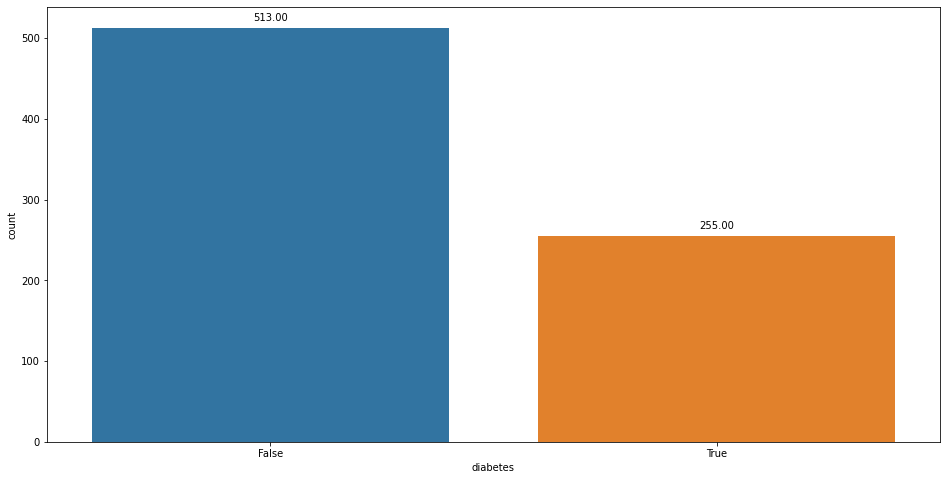

In [17]:
# Categorical attributes visulisation
plt.figure(figsize=(16, 8))
splot = sns.countplot(df['diabetes'])
for p in splot.patches:
    splot.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

# BAR GRAPH ( BETWEEN AGE AND BMI)

A BMI of between 18.5 and 24.9 is ideal


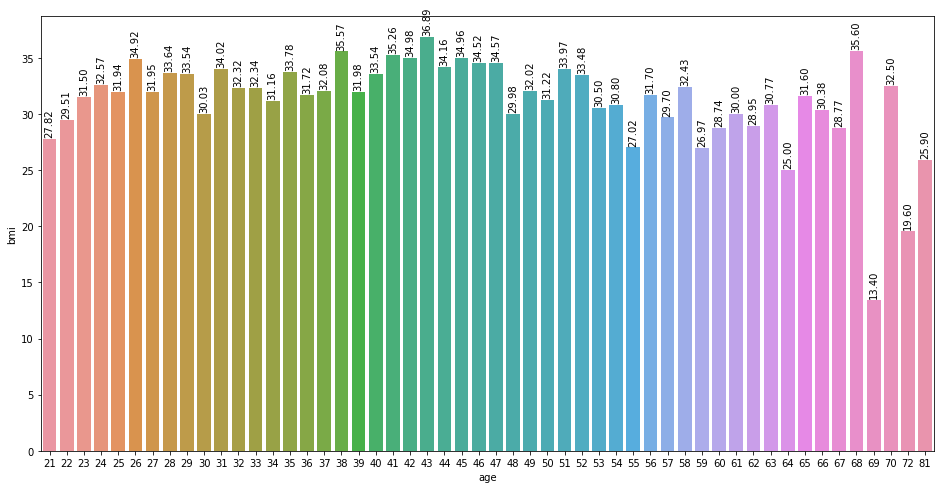

In [18]:
print("A BMI of between 18.5 and 24.9 is ideal")
plt.figure(figsize=(16,8))
splot = sns.barplot(data=df, x = 'age', y = 'bmi', ci = None)
for p in splot.patches:
    splot.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 16), rotation = 90, textcoords = 'offset points')

# BOX PLOT

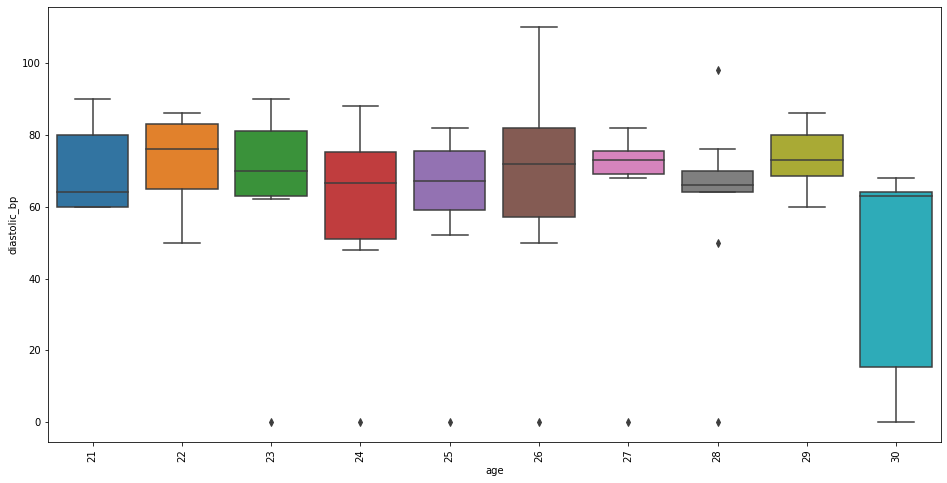

In [19]:
# person below 30 having diabetes
df_30=df[df['age']<=30]
df_30=df_30[df_30['diabetes']==True]

plt.rcParams['figure.figsize']=(16,8)
ax = sns.boxplot(x="age", y="diastolic_bp", data=df_30)
plt.xticks(rotation=90)

plt.show()

# LABEL-ENCODING

CHANGING THE CATEGORICAL VALUE TO NUMERICAL VALUE I.E. BOOLEAN TO NUMBER

In [20]:
# Import label encoder 
from sklearn import preprocessing 

# label_encoder object knows how to understand word labels. 
label_encoder = preprocessing.LabelEncoder() 

# Encode labels in column 'diabetes'. 
df['diabetes']= label_encoder.fit_transform(df['diabetes']) 

df['diabetes'].unique() 

array([1, 0], dtype=int64)

In [21]:
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,35,0.0,33.6,0.627,50,1.3790,1
1,1,85,66,29,0.0,26.6,0.351,31,1.1426,0
2,8,183,64,0,0.0,23.3,0.672,32,0.0000,1
3,1,89,66,23,94.0,28.1,0.167,21,0.9062,0
4,0,137,40,35,168.0,43.1,2.288,33,1.3790,1


In [22]:
diabetes_true_count = len(df.loc[df['diabetes']==True])
diabetes_false_count = len(df.loc[df['diabetes']==False])

In [23]:
print("True count:",diabetes_true_count)
print("False count:",diabetes_false_count)

True count: 255
False count: 513


# FEATURE SELECTION

### Chi-Squared / χ2 test

Selecting best features to use for model training

In [24]:
x = df.iloc[:,0:10] #independent columns
y = df.iloc[:,-1]   #target column i.e chances of having diabetes or not [0 or 1]

In [25]:
#apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=8)
fit = bestfeatures.fit(x,y)

In [26]:
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(x.columns)

In [27]:
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns

In [28]:
featureScores

,Specs,Score
0,num_preg,113.389232
1,glucose_conc,1354.291045
2,diastolic_bp,19.500849
3,thickness,58.976414
4,insulin,3054.124060
5,bmi,107.531673
6,diab_pred,5.512583
7,age,169.475055
8,skin,2.323671
9,diabetes,513.000000


##### Here we have total 10 features, higher the score more important the feature is, insulin has the max value thus making it the most important feature, the values that are higher are much more cor-related and important.

In [29]:
print(featureScores.nlargest(10,'Score'))  #print 10 best features

          Specs        Score
4       insulin  3054.124060
1  glucose_conc  1354.291045
9      diabetes   513.000000
7           age   169.475055
0      num_preg   113.389232
5           bmi   107.531673
3     thickness    58.976414
2  diastolic_bp    19.500849
6     diab_pred     5.512583
8          skin     2.323671


In [30]:
# Visualisation of best features in Descending Order

<Figure size 360x360 with 0 Axes>

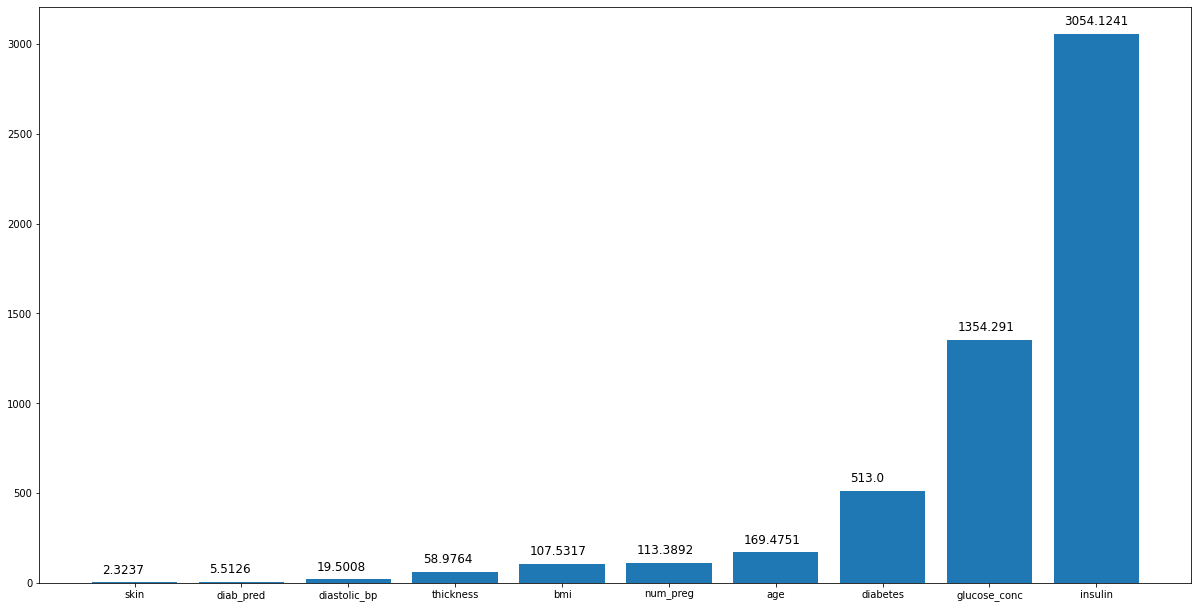

In [31]:
plt.figure(figsize=(5,5))
featureScores = featureScores.sort_values('Score')
featureScores
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.bar(featureScores['Specs'],featureScores['Score'])
for i in ax.patches:
    # get_x pulls left or right; get_height pushes up or down
    ax.text(i.get_x()+0.1, i.get_height()+51, \
            str(round((i.get_height()/100)*100, 4)), fontsize=12,
                color='black',rotation=0)
plt.show()

# TRAIN TEST SPLITTING

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
df.keys()

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin',
       'bmi', 'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

From all the 10 features we use the best 6 features for our dataset i.e. 
('num_preg', 'glucose_conc', 'thickness', 'insulin','bmi', 'age') 
and we use ("diabetes") as predicted column.

In [34]:
feature_columns = ['num_preg', 'glucose_conc', 'thickness', 'insulin','bmi', 'age']
predicted_column = ['diabetes']

In [35]:
x = df[feature_columns].values
y = df[predicted_column].values

In [36]:
# we split training and test data into 20-80 rato and add random state = 5

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y ,test_size = 0.20 ,random_state = 5)

In [38]:
# here we use standard scaler as it ransforms the data in such a manner that it has mean as 0 and standard deviation as 1.
# It arranges the data in a standard normal distribution and is useful in classification than regression.

In [39]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test)

In [40]:
print("X_train = ",X_train.shape ,", X_test =" , X_test.shape)

X_train =  (614, 6) , X_test = (154, 6)


In [41]:
X_train , X_test

(array([[-0.24152934,  0.22455976, -1.31684684, -0.71865847, -1.35714472,
          1.82612138],
        [ 2.41721789, -1.05299125,  1.2187673 , -0.24068439,  0.41977309,
          1.23838215],
        [ 1.82638517, -0.41421574, -1.31684684, -0.71865847,  0.05688142,
          0.73460566],
        ...,
        [ 0.05388702, -0.76554227,  0.14113129, -0.71865847, -0.46868582,
         -0.94464928],
        [ 0.64471974,  0.12874343,  0.64825412, -0.71865847, -0.54376685,
          1.32234489],
        [ 1.23555246,  2.39639647,  0.52147341,  1.75972568,  0.69507021,
          1.99404687]]),
 array([[ 6.44719740e-01, -9.25236147e-01,  7.11644472e-01,
          3.96614398e-01,  6.82740132e-03,  1.07045665e+00],
        [ 3.49303382e-01,  3.52314861e-01, -1.31684684e+00,
         -7.18658473e-01, -6.43874895e-01,  3.00159984e+00],
        [-2.41529335e-01, -4.78093295e-01, -1.31684684e+00,
         -7.18658473e-01, -7.69009952e-01, -5.24835543e-01],
        [ 5.38870230e-02, -7.01664721e-0

In [42]:
y_train , y_test

(array([[0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [1],
        [0],
        [0],
        [1],
        [0],
        [0],
        [1],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],

In [43]:
df.keys()

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin',
       'bmi', 'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

In [44]:
print("total number of rows : {0}".format(len(df)))
print("number of rows missing glucose_conc: {0}".format(len(df.loc[df['glucose_conc'] == 0])))
print("number of rows missing diastolic_bp: {0}" .format(len(df.loc[df['diastolic_bp'] == 0])))
print("number of rows missing thickness: {0}" .format(len(df.loc[df['thickness'] == 0])))
print("number of rows missing insulin: {0}" .format(len(df.loc[df['insulin'] == 0])))
print("number of rows missing bmi: {0}" .format(len(df.loc[df['bmi'] == 0])))
print("number of rows missing diab_pred: {0}" .format(len(df.loc[df['diab_pred'] == 0])))
print("number of rows missing age: {0}" .format(len(df.loc[df['age'] == 0])))
print("number of rows missing skin: {0}" .format(len(df.loc[df['skin'] == 0])))

total number of rows : 768
number of rows missing glucose_conc: 5
number of rows missing diastolic_bp: 35
number of rows missing thickness: 227
number of rows missing insulin: 372
number of rows missing bmi: 11
number of rows missing diab_pred: 0
number of rows missing age: 0
number of rows missing skin: 227


# Classifier

1. Logistic Regression 
2. Random Forest Classifier
3. KNN Classifier / Cross Validation
4. Decision Tree Classifier 
5. Naive Bayes

# LOGISTIC REGRESSION

In [45]:
# Fitting Logistic Regression to the Training set
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [46]:
y_predict_train = classifier.predict(X_train)

In [47]:
y_predict_test = classifier.predict(X_test)

In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       102
           1       0.73      0.62      0.67        52

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.76       154
weighted avg       0.79      0.79      0.79       154



## Accuracy

In [49]:
from sklearn import metrics
ac_LR=metrics.accuracy_score(y_test, y_predict_test)*100
print("Accuracy:",ac_LR)

Accuracy: 79.22077922077922


# RANDOM FOREST CLASSIFIER

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
model = RandomForestClassifier(random_state=10)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=10)

In [52]:
print(model)

RandomForestClassifier(random_state=10)


In [53]:
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]

# Accuracy

In [54]:
ac_RF=model.score(X_test, y_test)*100
print("Accuracy ", ac_RF)

Accuracy  75.32467532467533


# KNN CLASSIFIER USING CV

In [55]:
from sklearn.neighbors import KNeighborsClassifier

In [56]:
from sklearn.model_selection import cross_val_score
knn_scores = []
for k in range(1,21):
    knn_classifier = KNeighborsClassifier(n_neighbors = k)
    score=cross_val_score(knn_classifier,x_train,y_train,cv=10)
    knn_scores.append(score.mean())

Text(0.5, 1.0, 'K Neighbors Classifier scores for different K values')

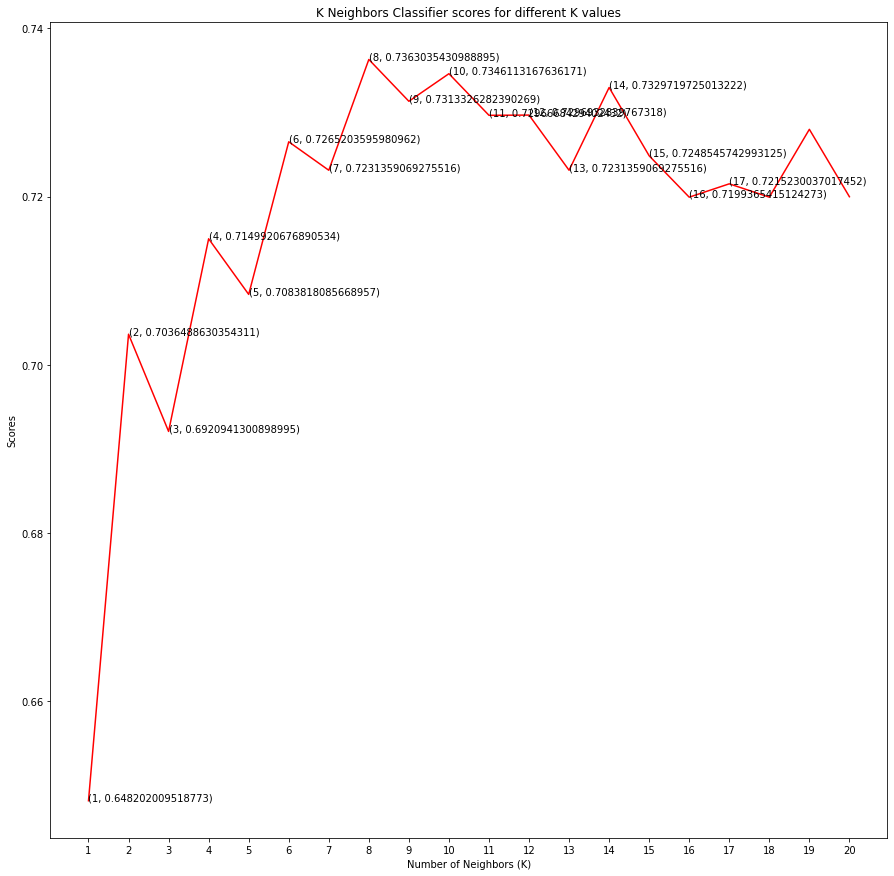

In [57]:
plt.figure(figsize=(15,15))
plt.plot([k for k in range(1, 21)], knn_scores, color = 'red')
for i in range(1,18):
    plt.text(i, knn_scores[i-1], (i, knn_scores[i-1]))
plt.xticks([i for i in range(1, 21)])
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Scores')
plt.title('K Neighbors Classifier scores for different K values')

In [58]:
knn_classifier = KNeighborsClassifier(n_neighbors = 20)
score=cross_val_score(knn_classifier,x_train,y_train,cv=10)

## Accuracy / Score

In [59]:
#evaluting predictions
ac_KNN=accuracy_score(y_test,y_pred)*100
print("Accuracy:",ac_KNN)

Accuracy: 75.32467532467533


# Decision Trees

In [60]:
from sklearn.tree import DecisionTreeClassifier 

In [61]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(x_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(x_test)

In [62]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm,columns=['Predicted No','Predicted Yes'],index=['Actual No','Actual Yes'])

,Predicted No,Predicted Yes
Actual No,81,21
Actual Yes,21,31


In [63]:
# Classification report

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       102
           1       0.60      0.60      0.60        52

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



# Accuracy

In [64]:
ac_DT = accuracy_score(y_test, y_pred)*100
print("Accuracy",ac_DT)

Accuracy 72.72727272727273


# Naive Bayes

In [65]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(x_train, y_train)

GaussianNB()

In [66]:
y_pred  =  classifier.predict(x_test)

In [67]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       102
           1       0.65      0.58      0.61        52

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



In [68]:
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

In [69]:
pd.DataFrame(cm,columns=['Predicted No','Predicted Yes'],index=['Actual No','Actual Yes'])

,Predicted No,Predicted Yes
Actual No,86,16
Actual Yes,22,30


In [70]:
print(cr)

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       102
           1       0.65      0.58      0.61        52

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



In [71]:
ac_NB = accuracy_score(y_test,y_pred)*100
print("Accuracy:",ac_NB)

Accuracy: 75.32467532467533


# Summary

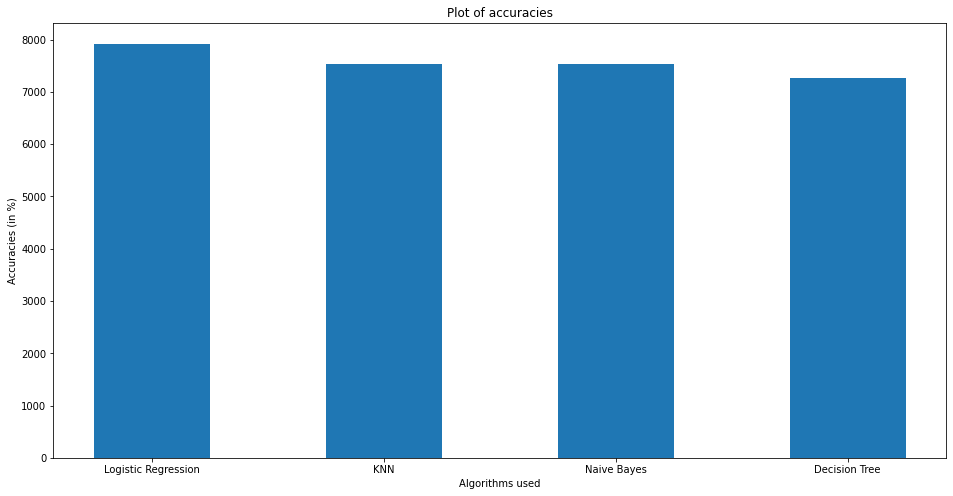

In [72]:
plt.bar(["Logistic Regression", "KNN", "Naive Bayes", "Decision Tree"],[ac_LR*100, ac_KNN*100, ac_NB*100, ac_DT*100], width=0.5)
plt.xlabel("Algorithms used")
plt.ylabel("Accuracies (in %)")
plt.title("Plot of accuracies")
plt.show()